<a href="https://colab.research.google.com/github/mszhdgr/Machine_learning/blob/Main/Deep%20Learning/pytorchbasis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch
torch.__version__

'2.10.0+cpu'

## Linear Regression

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [25]:
x = np.array(list(range(0, 1000,2))).reshape(-1, 1)
x[:5], len(x)

(array([[0],
        [2],
        [4],
        [6],
        [8]]),
 500)

In [26]:
m = 0.3
c = 0.7
y = m * x + c

In [27]:
y[:5]

array([[0.7],
       [1.3],
       [1.9],
       [2.5],
       [3.1]])

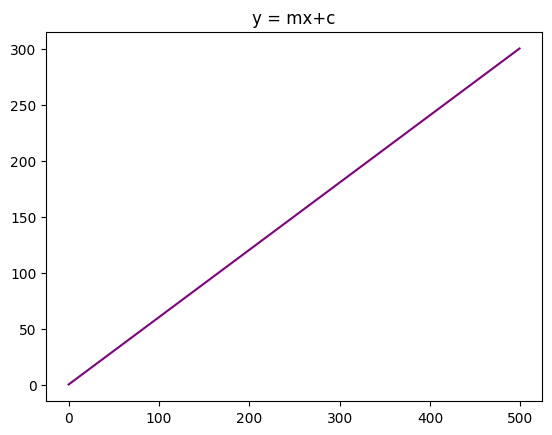

In [23]:
plt.plot(y, c="purple")
plt.title("y = mx+c")
plt.show()

In [44]:
x_tens = torch.from_numpy(x).float()
y_tens = torch.from_numpy(y).float()

In [46]:
from torch import nn

class LinearRegModel(nn.Module):
  def __init__(self, inf, ouf):
    super().__init__()
    self.layer = nn.Linear(inf, ouf)
  def forward(self, x):
    return self.layer(x)

In [47]:
model = LinearRegModel(1, 1)
model

LinearRegModel(
  (layer): Linear(in_features=1, out_features=1, bias=True)
)

In [45]:
x_tens[5]

tensor([10.])

In [48]:
with torch.inference_mode():
  logits = model(x_tens[5].float())

logits

tensor([-8.4149])

In [52]:
from torch.nn import L1Loss
from torch.optim import SGD

optimizer = SGD(params=model.parameters(), lr=0.01)
criterion = L1Loss()

In [58]:
E = []
L = []
for epoch in range(20):
  pred = model(x_tens.float())
  loss = criterion(pred, y_tens)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if epoch % 2 == 0:
    print(f"\n__epoch__: {epoch}\n")
    print(f"loss: {loss:.5f}")
    E.append(epoch)
    L.append(loss.item())


__epoch__: 0

loss: 0.20535

__epoch__: 2

loss: 0.20531

__epoch__: 4

loss: 0.20527

__epoch__: 6

loss: 0.20523

__epoch__: 8

loss: 0.20519

__epoch__: 10

loss: 0.20515

__epoch__: 12

loss: 0.20511

__epoch__: 14

loss: 0.20507

__epoch__: 16

loss: 0.20503

__epoch__: 18

loss: 0.20499


In [59]:
E

[0, 2, 4, 6, 8, 10, 12, 14, 16, 18]

In [60]:
L

[0.20535336434841156,
 0.20531076192855835,
 0.2052680104970932,
 0.20523354411125183,
 0.2051914781332016,
 0.20515261590480804,
 0.20511208474636078,
 0.20507125556468964,
 0.20503117144107819,
 0.20499034225940704]

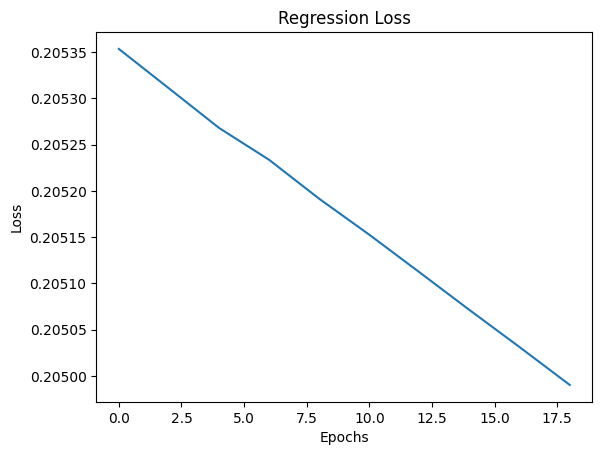

In [62]:
plt.plot(E, L)
plt.title("Regression Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

## Binary Classification

In [95]:
from sklearn.datasets import make_circles

x, y = make_circles(n_samples=1000, noise=0.02, random_state=42)

In [96]:
x

array([[ 0.76026594,  0.22387823],
       [-0.76722217,  0.1455425 ],
       [-0.80815854,  0.14894355],
       ...,
       [-0.14123526, -0.80195115],
       [ 0.67509008, -0.75465723],
       [ 0.28237752,  0.96205688]])

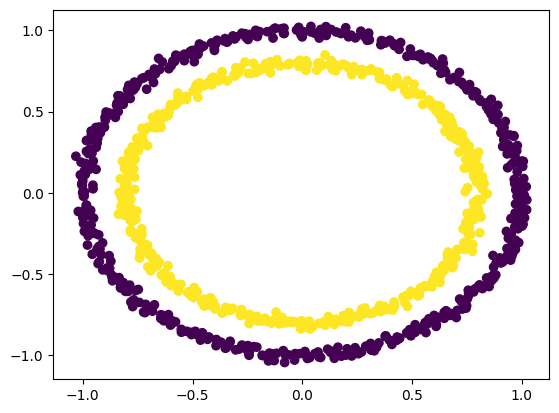

In [97]:
plt.scatter(x[:,0], x[:,1], c=y)
plt.show()

In [98]:
X = torch.from_numpy(x)
Y = torch.from_numpy(y)

In [99]:
X

tensor([[ 0.7603,  0.2239],
        [-0.7672,  0.1455],
        [-0.8082,  0.1489],
        ...,
        [-0.1412, -0.8020],
        [ 0.6751, -0.7547],
        [ 0.2824,  0.9621]], dtype=torch.float64)

In [100]:
xtrain, xtest = X[:800], X[800:]
ytrain, ytest = Y[:800], Y[800:]
len(ytrain), len(ytest)

(800, 200)

In [101]:
class BinaryClassifier(nn.Module):
  def __init__(self, inp, oup, hid):
    super().__init__()
    self.l1 = nn.Linear(inp, hid)
    self.relu = nn.ReLU()
    self.l2 = nn.Linear(hid, oup)
  def forward(self, x):
    x = self.l1(x)
    x = self.relu(x)
    x = self.l2(x)
    return x

In [102]:
model_0 = BinaryClassifier(2, 1, 8)
model_0

BinaryClassifier(
  (l1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (l2): Linear(in_features=8, out_features=1, bias=True)
)

In [103]:
xtrain[0]

tensor([0.7603, 0.2239], dtype=torch.float64)

In [104]:
ytrain[0]

tensor(1)

In [105]:
with torch.inference_mode():
  logits = model_0(xtrain[0].float())

logits

tensor([0.1783])

In [106]:
torch.round(torch.sigmoid(logits))

tensor([1.])

In [111]:
from torch.nn import BCEWithLogitsLoss

criterion = BCEWithLogitsLoss()
optimizer = SGD(params=model_0.parameters(), lr=0.1)

In [117]:
for epoch in range(1000):
  model_0.train()
  logits = model_0(xtrain.float())
  loss = criterion(logits, ytrain.unsqueeze(1).float())
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if epoch % 100 == 0:
    print(f"\n__epoch__: {epoch}\n")
    print(f"loss: {loss:.5f}")


__epoch__: 0

loss: 0.68455

__epoch__: 100

loss: 0.67952

__epoch__: 200

loss: 0.67406

__epoch__: 300

loss: 0.66783

__epoch__: 400

loss: 0.66060

__epoch__: 500

loss: 0.65211

__epoch__: 600

loss: 0.64187

__epoch__: 700

loss: 0.62957

__epoch__: 800

loss: 0.61579

__epoch__: 900

loss: 0.60040


In [118]:
xtest[0], ytest[0]

(tensor([0.6165, 0.5103], dtype=torch.float64), tensor(1))

In [121]:
with torch.inference_mode():
  lg = model_0(xtest[0].float())

lg

tensor([0.1214])

In [122]:
torch.round(torch.sigmoid(lg))

tensor([1.])

## Multiclass Classification

In [156]:
from sklearn.datasets import load_iris

iris = load_iris()
x = iris.data
y = iris.target

In [157]:
x[:5]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2]])

In [158]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [159]:
class Multiclass(nn.Module):
  def __init__(self, inp, oup, hid):
    super().__init__()
    self.layer = nn.Sequential(
        nn.Linear(inp, hid),
        nn.ReLU(),
        nn.Linear(hid, oup)
    )
  def forward(self, x):
    return self.layer(x)

In [160]:
model_1 = Multiclass(inp=4, oup=3, hid=8)
model_1

Multiclass(
  (layer): Sequential(
    (0): Linear(in_features=4, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=3, bias=True)
  )
)

In [161]:
len(y)

150

In [162]:
from sklearn.model_selection import train_test_split
x = torch.from_numpy(x).float()
y = torch.from_numpy(y).long()

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

len(ytrain), len(ytest)

(105, 45)

In [163]:
xtrain[0]

tensor([5.1000, 2.5000, 3.0000, 1.1000])

In [164]:
with torch.inference_mode():
  lg = model_1(xtrain[0].float())

lg

tensor([-0.6926,  0.5753,  0.5770])

In [165]:
torch.argmax(torch.softmax(lg, dim=0))

tensor(2)

In [166]:
from torch.nn import CrossEntropyLoss

criterion = CrossEntropyLoss()
optimizer = SGD(model_1.parameters(), lr=0.1)

In [167]:
for epoch in range(100):
  model_1.train()
  lg = model_1(xtrain.float())
  pred = torch.argmax(torch.softmax(lg, dim=0))
  loss = criterion(lg, ytrain)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  if epoch % 10 == 0:
    print(f"\n__epoch__: {epoch}\n")
    print(f"loss: {loss:.5f}")


__epoch__: 0

loss: 1.30403

__epoch__: 10

loss: 0.95498

__epoch__: 20

loss: 0.72077

__epoch__: 30

loss: 0.54871

__epoch__: 40

loss: 0.45938

__epoch__: 50

loss: 0.39988

__epoch__: 60

loss: 0.35095

__epoch__: 70

loss: 0.30992

__epoch__: 80

loss: 0.53759

__epoch__: 90

loss: 0.34285


In [168]:
xtest[10], ytest[10]

(tensor([5.8000, 4.0000, 1.2000, 0.2000]), tensor(0))

In [169]:
with torch.inference_mode():
  lg = model_1(xtest[10].float())
lg

tensor([ 5.2042,  0.5592, -5.3408])

In [170]:
torch.argmax(torch.softmax(lg, dim=0), dim=0)

tensor(0)